# Import config file which stores all hyperparameter values

In [1]:
import os 
import configparser

In [2]:
config_path = "configs/Training_config.ini"
config_read = configparser.ConfigParser()
config_read.read(config_path)

['configs/Training_config.ini']

In [3]:
for sect in config_read.sections():
    print('Title:', sect)
    for k,v in config_read.items(sect):
        print(' {} = {}'.format(k,v))
    print()

Title: TrainingInfo
 traindataset = ['jaadbeh_with_c_g/train/']
 loss = BCE
 save_model_folder_acc = training_results/best_val_acc/
 save_model_folder_f1 = training_results/best_val_f1/
 batch_size = 100
 stratifiedkfold_random_state = 1
 graph_seed = 2676
 1dcnn_seed = 2726



In [4]:
import json
train_folder = json.loads(config_read.get("TrainingInfo", "traindataset").replace("'",'"'))
loss_name = config_read.get("TrainingInfo", "loss")
save_model_folder_acc = config_read.get("TrainingInfo", "save_model_folder_acc")
save_model_folder_f1 = config_read.get("TrainingInfo", "save_model_folder_f1")
batch_size = int(config_read.get("TrainingInfo", "batch_size"))
ran_2 = int(config_read.get("TrainingInfo", "stratifiedkfold_random_state"))

In [5]:
train_folder

['jaadbeh_with_c_g/train/']

# Load training data 

In [6]:
import os

In [7]:
import numpy as np


In [8]:
root = 'preprocessed_data/jaadbeh_with_c_g/test/'
x_t_test, y_t_test = np.load(root + 'x_t.npy'), np.load(root + 'y.npy')


In [9]:
print(x_t_test.shape, y_t_test.shape)

(18790, 16, 5) (18790, 1)


In [10]:
def count_imbalance(y_t):
    count_pos, count_neg = 0, 0
    for label in y_t:
        if label == [1.0]:
            count_pos+=1
        else:
            count_neg+=1
    if count_pos>count_neg:
        print('Negative class is minority class')
    else:
        print('Positive class is minority class')
        
    print('Imbalance ratio: {0}:{1}'.format(str(round(count_pos/len(y_t),2)), str(round(count_neg/len(y_t),2))))
    print('Number of sample deficit: {0}'.format(str(abs(count_pos-count_neg))))
    return count_pos/(count_pos+count_neg)

In [11]:
alpha = count_imbalance(y_t_test)

Positive class is minority class
Imbalance ratio: 0.43:0.57
Number of sample deficit: 2588


# Prepare a training function

In [12]:
# import os
# import torch 
# import numpy as np
# import utils.data_loader as Dataset
# from torch.utils.data import DataLoader
# import models.pedgraph_model as Ped
# import pandas as pd

In [13]:
import torch

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

X_test = x_t_test
y_test = y_t_test

In [14]:
X_test.shape, y_test.shape

((18790, 16, 5), (18790, 1))

# ablation model anaylsis

________________________________________
start evaluating fold: 1


/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


Confusion martrix: 


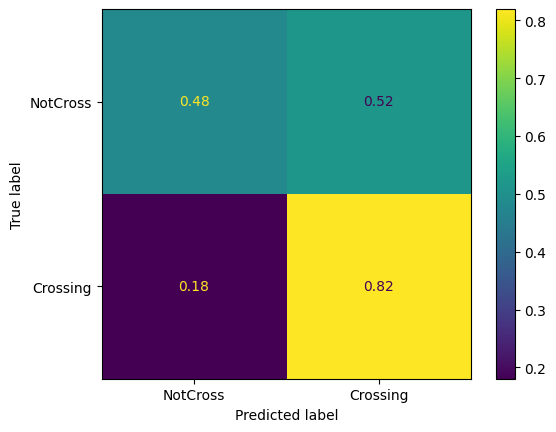

________________________________________
start evaluating fold: 2
Confusion martrix: 


/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


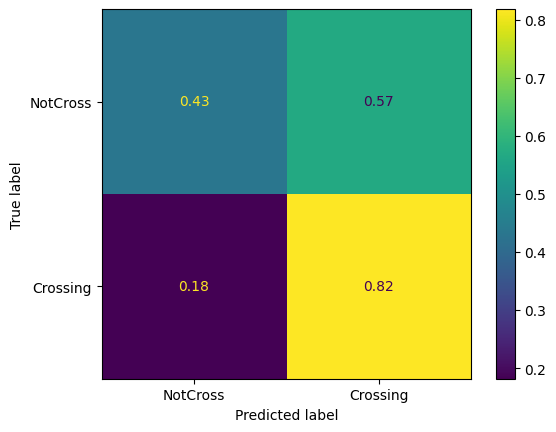

________________________________________
start evaluating fold: 3


/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


Confusion martrix: 


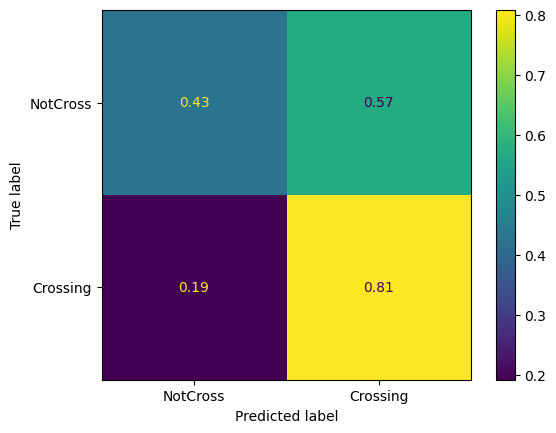

________________________________________
start evaluating fold: 4


/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


Confusion martrix: 


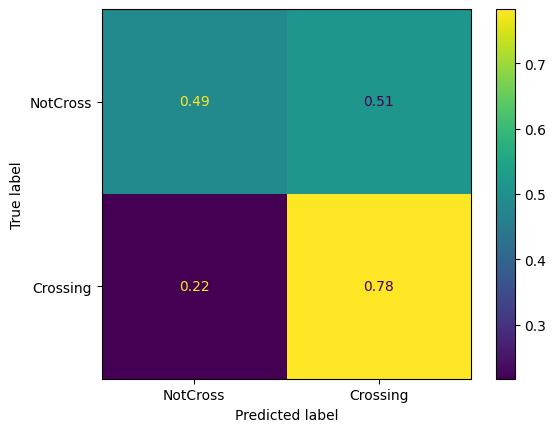

________________________________________
start evaluating fold: 5


/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


Confusion martrix: 


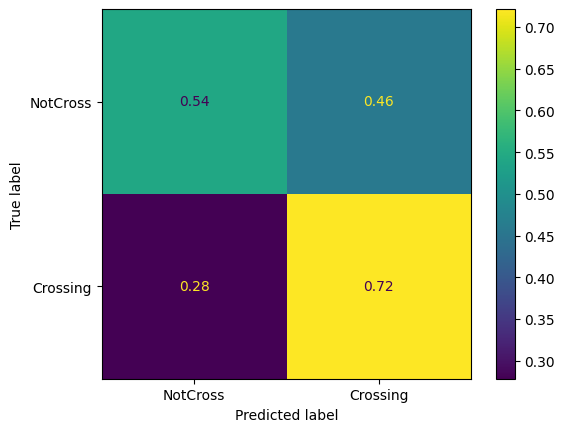

Averaging scores for all folds stats: 
avg_acc: 0.61
avg_auc: 0.69
avg_f1: 0.61
avg_pr: 0.64
avg_re: 0.63


In [15]:
import numpy as np
from model_evaluation.performance_scores import *
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from model_evaluation.model_predictions import predict_1dcnn_addfeatures
from model_evaluation.performance_scores import get_precision_recall_F1, calculate_acc
import matplotlib.pyplot as plt
k = 5
avg_pr = []
avg_re = []
avg_f1 = []

avg_auc = []
avg_acc = []

model_folder = "best_val_f1/"

preds_li = []
y_li = []
probs_li =[]

for i in range(k):
    print('_'*40)
    print('start evaluating fold: {0}'.format(i+1))
    sub_model_folder = model_folder+'fold_{0}/'.format(i+1)
    FC_outputs = predict_1dcnn_addfeatures(sub_model_folder, X_test, device, 'f1')#FC_outputs: outputs of the last FC
    probs = torch.sigmoid(FC_outputs).cpu().detach()
    preds = torch.round(probs)
    preds = preds.numpy()
    if not type(y_test)== np.ndarray:
        y_test = y_test.cpu().detach().numpy()
    acc= calculate_acc(preds, y_test)
    p,re,f1,auc = get_precision_recall_F1(preds, y_test, probs)
    acc = calculate_acc(preds, y_test)
    avg_pr.append(float(p))
    avg_re.append(float(re))
    avg_f1.append(float(f1))
    avg_auc.append(float(auc))
    avg_acc.append(acc)
    print('Confusion martrix: ')
    # preds = preds.astype(int)
    preds_li.extend(np.squeeze(preds).tolist())
    probs_li.extend(np.squeeze(probs).tolist())
    y_li.extend(y_test.tolist())
    
    confusion_matrix = metrics.confusion_matrix(y_test,preds, normalize='true')
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ['NotCross', 'Crossing'])
    cm_display.plot()
    plt.show()
    
       
    
print('='*40)
print('Averaging scores for all folds stats: ')
print("avg_acc: {:.2f}".format(sum(avg_acc)/len(avg_acc)))
print('avg_auc: {:.2f}'.format(sum(avg_auc)/len(avg_auc))) 
print('avg_f1: {:.2f}'.format(sum(avg_f1)/len(avg_f1)))
print('avg_pr: {:.2f}'.format(sum(avg_pr)/len(avg_pr)))
print('avg_re: {:.2f}'.format(sum(avg_re)/len(avg_re)))  

In [16]:
print(len(y_li) == len(preds_li) == len(probs_li))

True


In [17]:
print(len(y_li))

93950


In [18]:
import json

In [19]:
results = {'x3':{}}
results['x3'] = {'probs':probs_li, 'preds': preds_li, 'test_gts': y_li}

In [20]:
results.keys()

dict_keys(['x3'])

In [21]:
with open('JAADbeh_results.json', 'w') as f:
    json.dump(results, f)